In [94]:
# ===========================
# Install Required Packages
# ===========================

!pip install -q torch torchvision torchaudio
!pip install -q pandas numpy matplotlib tqdm
!pip install -q nltk
!pip install -q bert-score
!pip install -q sacrebleu
!pip install -q sentencepiece
!pip install -q scikit-learn

import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [95]:
import os
import time
import random
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split

from nltk.translate.bleu_score import corpus_bleu

from bert_score import score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [97]:
import pandas as pd
import os

DATASET_PATH = "/content/drive/MyDrive/"

train_en = pd.read_csv(os.path.join(DATASET_PATH, "train_en_10000.csv"))
train_sa = pd.read_csv(os.path.join(DATASET_PATH, "train_sa_10000.csv"))

dev_en = pd.read_csv(os.path.join(DATASET_PATH, "dev_en_1000.csv"))
dev_sa = pd.read_csv(os.path.join(DATASET_PATH, "dev_sa_1000.csv"))

test_en = pd.read_csv(os.path.join(DATASET_PATH, "test_en_1000.csv"))
test_sa = pd.read_csv(os.path.join(DATASET_PATH, "test_sa_1000.csv"))



In [98]:
print(train_sa.head())

print(train_en.head())

print(train_sa.shape)
print(train_en.shape)

   Source_id                                        Sentence_sa
0          1                         "Ctrl, S नुत्वा रक्षन्तु।"
1          2                     गुरुः छात्रान् एकवारं पाठयति ।
2          3  चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...
3          4       वयं  Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।
4          5  "अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...
   Source_id                                        Sentence_en
0          1                              Save it with Ctrl, S.
1          2         Teacher will teach the students only once.
2          3  To recreate this animation, I have to take two...
3          4    I will choose Colors options by clicking on it.
4          5  "See the example here - one mountain, four vil...
(10000, 2)
(10000, 2)


In [99]:
train = train_sa.merge(train_en,on="Source_id")

dev = dev_sa.merge(dev_en,on="Source_id")

test = test_sa.merge(test_en,on="Source_id")
train.head() #verifying

,Source_id,Sentence_sa,Sentence_en
0,1,"""Ctrl, S नुत्वा रक्षन्तु।""","Save it with Ctrl, S."
1,2,गुरुः छात्रान् एकवारं पाठयति ।,Teacher will teach the students only once.
2,3,चित्रचालनमिदं पुनः कर्तुं मया अस्याः राशेः चित...,"To recreate this animation, I have to take two..."
3,4,वयं Colors विकल्पं तस्योपरि नोदनेन चिनुमः ।,I will choose Colors options by clicking on it.
4,5,"""अत्र कानिचन उदाहरणानि पश्याम:- एक: पर्वत:, चत...","""See the example here - one mountain, four vil..."


In [100]:
# deleting null values if any
print(train.isnull().sum())

print(dev.isnull().sum())

print(test.isnull().sum())

train = train.dropna()

dev = dev.dropna()

test = test.dropna()

Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64
Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64
Source_id      0
Sentence_sa    0
Sentence_en    0
dtype: int64


In [101]:
# check duplicate
print(train.duplicated().sum())

# Sentence Length Statistics
train["sa_len"] = train["Sentence_sa"].apply(lambda x: len(str(x).split()))

train["en_len"] = train["Sentence_en"].apply(lambda x: len(str(x).split()))

0


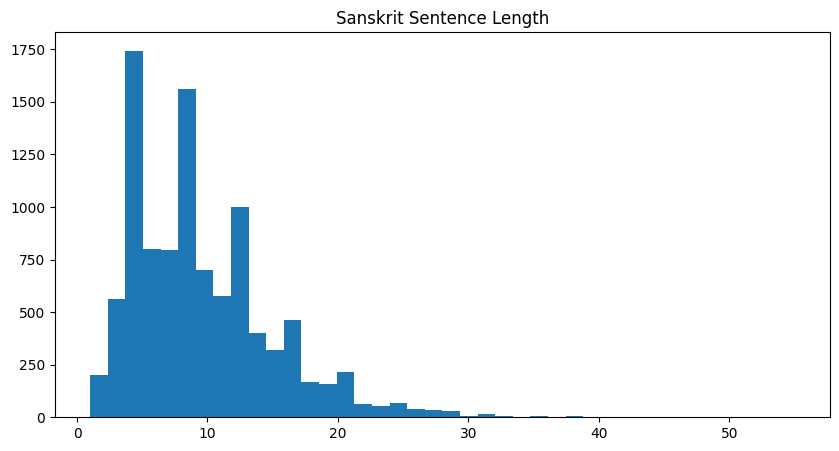

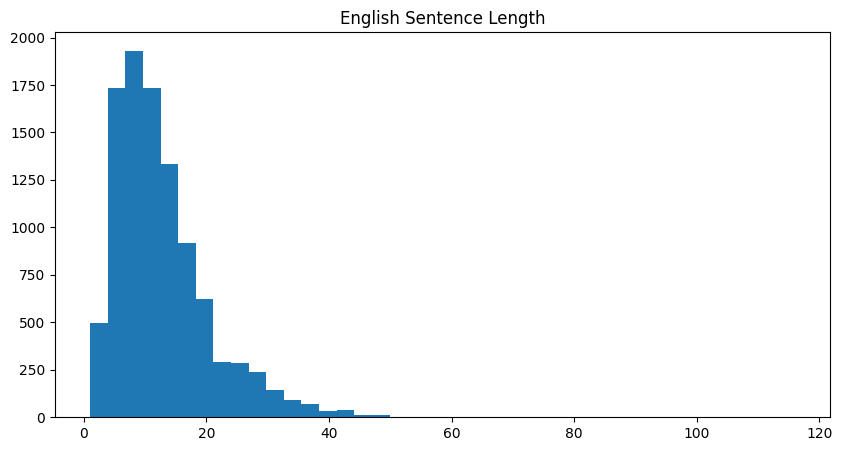

Training Sentences : 10000
Validation Sentences : 1000
Testing Sentences : 1000

Average Sanskrit Length
9.6678

Average English Length
12.6439


In [102]:
plt.figure(figsize=(10,5))

plt.hist(train["sa_len"],bins=40)

plt.title("Sanskrit Sentence Length")

plt.show()

plt.figure(figsize=(10,5))

plt.hist(train["en_len"],bins=40)

plt.title("English Sentence Length")

plt.show()

print("Training Sentences :",len(train))

print("Validation Sentences :",len(dev))

print("Testing Sentences :",len(test))

print()

print("Average Sanskrit Length")

print(train.sa_len.mean())

print()

print("Average English Length")

print(train.en_len.mean())

In [103]:
# ===========================
# Reproducibility
# ===========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

In [104]:
import re

def clean_sanskrit(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def clean_english(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


train["Sentence_sa"] = train["Sentence_sa"].apply(clean_sanskrit)
train["Sentence_en"] = train["Sentence_en"].apply(clean_english)

dev["Sentence_sa"] = dev["Sentence_sa"].apply(clean_sanskrit)
dev["Sentence_en"] = dev["Sentence_en"].apply(clean_english)

test["Sentence_sa"] = test["Sentence_sa"].apply(clean_sanskrit)
test["Sentence_en"] = test["Sentence_en"].apply(clean_english)

In [105]:
#Tokenization

def tokenize(text):
    return text.split()

In [106]:
from collections import Counter

def build_vocab(sentences, min_freq=2):

    counter = Counter()

    for sentence in sentences:
        counter.update(tokenize(sentence))

    vocab = {
        PAD_TOKEN: 0,
        SOS_TOKEN: 1,
        EOS_TOKEN: 2,
        UNK_TOKEN: 3
    }

    idx = len(vocab)

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = idx
            idx += 1

    return vocab



sa_vocab = build_vocab(train["Sentence_sa"])
en_vocab = build_vocab(train["Sentence_en"])

print("Sanskrit Vocabulary:", len(sa_vocab))
print("English Vocabulary :", len(en_vocab))

#Reverse Vocabulary
sa_idx2word = {v: k for k, v in sa_vocab.items()}
en_idx2word = {v: k for k, v in en_vocab.items()}
#Convert Sentence to IDs

def numericalize(sentence, vocab):

    tokens = tokenize(sentence)

    ids = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens]

    return ids

def encode_sentence(sentence, vocab):

    ids = numericalize(sentence, vocab)

    return (
        [vocab[SOS_TOKEN]]
        + ids
        + [vocab[EOS_TOKEN]]
    )

Sanskrit Vocabulary: 8485
English Vocabulary : 7072


In [107]:
MAX_SRC_LEN = max(
    train["Sentence_sa"].apply(lambda x: len(tokenize(x)))
) + 2

MAX_TRG_LEN = max(
    train["Sentence_en"].apply(lambda x: len(tokenize(x)))
) + 2

print(MAX_SRC_LEN)
print(MAX_TRG_LEN)

#Padding Function

def pad_sequence(sequence, max_len, pad_idx):

    if len(sequence) < max_len:
        sequence = sequence + [pad_idx] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]

    return sequence

57
118


In [108]:
class TranslationDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        src = encode_sentence(
            self.df.iloc[idx]["Sentence_sa"],
            sa_vocab
        )

        trg = encode_sentence(
            self.df.iloc[idx]["Sentence_en"],
            en_vocab
        )

        src = pad_sequence(
            src,
            MAX_SRC_LEN,
            sa_vocab[PAD_TOKEN]
        )

        trg = pad_sequence(
            trg,
            MAX_TRG_LEN,
            en_vocab[PAD_TOKEN]
        )

        return (
            torch.tensor(src),
            torch.tensor(trg)
        )




In [109]:
train_dataset = TranslationDataset(train)
dev_dataset = TranslationDataset(dev)
test_dataset = TranslationDataset(test)



BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

#verify pipeline
src, trg = next(iter(train_loader))

print(src.shape)
print(trg.shape)

torch.Size([64, 57])
torch.Size([64, 118])


In [110]:
import torch.nn as nn

# Build the Seq2Seq Model


#Encoder

class Encoder(nn.Module):

    def __init__(
        self,
        input_dim,
        emb_dim,
        hidden_dim,
        n_layers,
        dropout
    ):

        super().__init__()
        self.n_layers = n_layers # Store n_layers as an instance variable

        self.embedding = nn.Embedding(
            input_dim,
            emb_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            emb_dim,
            hidden_dim,
            num_layers=n_layers,
            dropout=dropout,
            bidirectional=True,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

        # Convert BiLSTM hidden state to Decoder size

        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)

        self.fc_cell = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src):

        embedded = self.dropout(
            self.embedding(src)
        )

        outputs, (hidden, cell) = self.lstm(embedded)

        # last forward + last backward

        hidden = torch.cat(
            (hidden[-2], hidden[-1]),
            dim=1
        )

        cell = torch.cat(
            (cell[-2], cell[-1]),
            dim=1
        )

        hidden = torch.tanh(
            self.fc_hidden(hidden)
        )

        cell = torch.tanh(
            self.fc_cell(cell)
        )

        # Replicate hidden and cell states for N_LAYERS to match Decoder's LSTM
        return outputs, hidden.unsqueeze(0).repeat(self.n_layers, 1, 1), cell.unsqueeze(0).repeat(self.n_layers, 1, 1)

#Bahdanau Attention

class BahdanauAttention(nn.Module):

    def __init__(self, hidden_dim):

        super().__init__()

        self.attn = nn.Linear(
            hidden_dim * 3,
            hidden_dim
        )

        self.v = nn.Linear(
            hidden_dim,
            1,
            bias=False
        )

    def forward(
        self,
        hidden,
        encoder_outputs
    ):

        batch_size = encoder_outputs.shape[0]
        src_len = encoder_outputs.shape[1]

        # hidden is (batch_size, 1, hidden_dim). We need to expand it to (batch_size, src_len, hidden_dim)
        hidden = hidden.repeat(1, src_len, 1)

        energy = torch.tanh(

            self.attn(

                torch.cat(
                    (hidden, encoder_outputs),
                    dim=2
                )

            )

        )

        attention = self.v(energy).squeeze(2)

        return torch.softmax(
            attention,
            dim=1
        )

# Decoder


class Decoder(nn.Module):

    def __init__(
        self,
        output_dim,
        emb_dim,
        hidden_dim,
        n_layers,
        dropout,
        attention
    ):

        super().__init__()

        self.output_dim = output_dim

        self.attention = attention

        self.embedding = nn.Embedding(
            output_dim,
            emb_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(

            hidden_dim*2 + emb_dim,

            hidden_dim,

            num_layers=n_layers,

            dropout=dropout,

            batch_first=True

        )

        self.fc = nn.Linear(

            hidden_dim*3 + emb_dim,

            output_dim

        )

        self.dropout = nn.Dropout(dropout)

    def forward(

        self,

        input,

        hidden,

        cell,

        encoder_outputs

    ):

        input = input.unsqueeze(1)

        embedded = self.dropout(

            self.embedding(input)

        )

        attention = self.attention(

            hidden[-1].unsqueeze(1),

            encoder_outputs

        )

        attention = attention.unsqueeze(1)

        context = torch.bmm(

            attention,

            encoder_outputs

        )

        lstm_input = torch.cat(

            (embedded,context),

            dim=2

        )

        output,(hidden,cell)=self.lstm(

            lstm_input,

            (hidden,cell)

        )

        prediction = self.fc(

            torch.cat(

                (

                    output.squeeze(1),

                    context.squeeze(1),

                    embedded.squeeze(1)

                ),

                dim=1

            )

        )

        return prediction,hidden,cell


#Wrapper

class Seq2Seq(nn.Module):

    def __init__(
        self,
        encoder,
        decoder,
        device
    ):

        super().__init__()

        self.encoder = encoder

        self.decoder = decoder

        self.device = device

    def forward(

        self,

        src,

        trg,

        teacher_forcing_ratio=0.5

    ):

        batch_size = trg.shape[0]

        trg_len = trg.shape[1]

        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(

            batch_size,

            trg_len,

            trg_vocab_size

        ).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src)

        input = trg[:,0]

        for t in range(1,trg_len):

            output,hidden,cell = self.decoder(

                input,

                hidden,

                cell,

                encoder_outputs

            )

            outputs[:,t] = output

            best_guess = output.argmax(1)

            teacher_force = random.random() < teacher_forcing_ratio

            input = trg[:,t] if teacher_force else best_guess

        return outputs


# initialize Model


INPUT_DIM = len(sa_vocab)

OUTPUT_DIM = len(en_vocab)

EMB_DIM = 256

HIDDEN_DIM = 256

N_LAYERS = 2

DROPOUT = 0.3

attention = BahdanauAttention(HIDDEN_DIM)

encoder = Encoder(

    INPUT_DIM,

    EMB_DIM,

    HIDDEN_DIM,

    N_LAYERS,

    DROPOUT

)

decoder = Decoder(

    OUTPUT_DIM,

    EMB_DIM,

    HIDDEN_DIM,

    N_LAYERS,

    DROPOUT,

    attention

)

model = Seq2Seq(

    encoder,

    decoder,

    device

).to(device)

print(model)


def count_parameters(model):

    return sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )

print(f"Trainable Parameters: {count_parameters(model):,}")


optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)

criterion = nn.CrossEntropyLoss(

    ignore_index=en_vocab[PAD_TOKEN]

)


CLIP = 1

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(8485, 256, padding_idx=0)
    (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (fc_hidden): Linear(in_features=512, out_features=256, bias=True)
    (fc_cell): Linear(in_features=512, out_features=256, bias=True)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (attn): Linear(in_features=768, out_features=256, bias=True)
      (v): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(7072, 256, padding_idx=0)
    (lstm): LSTM(768, 256, num_layers=2, batch_first=True, dropout=0.3)
    (fc): Linear(in_features=1024, out_features=7072, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)
Trainable Parameters: 15,897,760


In [ ]:
#****************************************************TRAINING THE MODEL *****************************************************************

from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

def train_epoch(
    model,
    dataloader,
    optimizer,
    criterion,
    clip,
    teacher_forcing_ratio=0.5
):

    model.train()

    epoch_loss = 0

    for src, trg in tqdm(dataloader):

        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = model(
            src,
            trg,
            teacher_forcing_ratio
        )

        output_dim = output.shape[-1]

        output = output[:,1:].reshape(-1, output_dim)

        trg = trg[:,1:].reshape(-1)

        loss = criterion(output, trg)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)


def evaluate(
    model,
    dataloader,
    criterion
):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for src, trg in dataloader:

            src = src.to(device)
            trg = trg.to(device)

            output = model(
                src,
                trg,
                teacher_forcing_ratio=0
            )

            output_dim = output.shape[-1]

            output = output[:,1:].reshape(
                -1,
                output_dim
            )

            trg = trg[:,1:].reshape(-1)

            loss = criterion(
                output,
                trg
            )

            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)


#EARLY STOPPING

class EarlyStopping:

    def __init__(

        self,

        patience=5,

        path="best_model.pt"

    ):

        self.patience = patience

        self.counter = 0

        self.best_loss = float("inf")

        self.path = path

    def step(

        self,

        val_loss,

        model

    ):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

            torch.save(

                model.state_dict(),

                self.path

            )

            return False

        else:

            self.counter += 1

            print(

                f"EarlyStopping Counter: {self.counter}"

            )

            return self.counter >= self.patience


# TRAINING HYPER PARAMETER


N_EPOCHS = 25

CLIP = 1

teacher_forcing = 0.7

teacher_decay = 0.95

early_stopping = EarlyStopping(
    patience=5
)

#START TRAINING

train_losses = []

valid_losses = []

for epoch in range(N_EPOCHS):

    print(f"\nEpoch {epoch+1}/{N_EPOCHS}")

    train_loss = train_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        CLIP,

        teacher_forcing

    )

    valid_loss = evaluate(

        model,

        dev_loader,

        criterion

    )

    scheduler.step(valid_loss)

    train_losses.append(train_loss)

    valid_losses.append(valid_loss)

    print(

        f"Train Loss: {train_loss:.4f}"

    )

    print(

        f"Validation Loss: {valid_loss:.4f}"

    )

    teacher_forcing *= teacher_decay

    stop = early_stopping.step(

        valid_loss,

        model

    )

    if stop:

        print("Early stopping triggered.")

        break


#LOAD BEST MODEL

model.load_state_dict(
    torch.load("best_model.pt")
)

#PLOT LEARNING CURVE

plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Training")

plt.plot(valid_losses,label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.title("Training Curve")

plt.show()


Epoch 1/25


100%|██████████| 157/157 [02:31<00:00,  1.04it/s]


Train Loss: 6.0731
Validation Loss: 5.6791

Epoch 2/25


100%|██████████| 157/157 [02:20<00:00,  1.12it/s]


Train Loss: 5.3852
Validation Loss: 5.5509

Epoch 3/25


...

100%|██████████| 157/157 [02:12<00:00,  1.18it/s]


Train Loss: 4.8248
Validation Loss: 5.3658

Epoch 5/25


100%|██████████| 157/157 [02:12<00:00,  1.18it/s]


Train Loss: 4.5956
Validation Loss: 5.3252

Epoch 6/25


 59%|█████▉    | 93/157 [01:19<00:53,  1.19it/s]

In [ ]:
# Beam Search Decoding**************************************************************

#We'll implement this first to verify the model.
def greedy_decode(
    model,
    sentence,
    max_len=50
):

    model.eval()

    src = encode_sentence(sentence, sa_vocab)

    src = pad_sequence(
        src,
        MAX_SRC_LEN,
        sa_vocab[PAD_TOKEN]
    )

    src = torch.LongTensor(src).unsqueeze(0).to(device)

    with torch.no_grad():

        encoder_outputs, hidden, cell = model.encoder(src)

    input_token = torch.LongTensor(
        [en_vocab[SOS_TOKEN]]
    ).to(device)

    outputs = []

    for _ in range(max_len):

        with torch.no_grad():

            prediction, hidden, cell = model.decoder(

                input_token,

                hidden,

                cell,

                encoder_outputs

            )

        best = prediction.argmax(1).item()

        if best == en_vocab[EOS_TOKEN]:
            break

        outputs.append(best)

        input_token = torch.LongTensor([best]).to(device)

    translated = [

        en_idx2word.get(idx, UNK_TOKEN)

        for idx in outputs

    ]

    return " ".join(translated)

#tEST gREEDY sEARCH
example = train.iloc[0]["Sentence_sa"]

print(example)

print()

print(greedy_decode(model, example))


#THE REAL BEAM SEARCH DECODER

import torch
import torch.nn.functional as F
import math


def beam_search_decode(
    model,
    sentence,
    beam_width=5,
    max_len=60,
    alpha=0.7,          # Length normalization
    unk_penalty=2.0,    # Penalize <unk>
    no_repeat=True
):

    model.eval()

    src = encode_sentence(sentence, sa_vocab)

    src = pad_sequence(
        src,
        MAX_SRC_LEN,
        sa_vocab[PAD_TOKEN]
    )

    src = torch.LongTensor(src).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src)

    beams = [{
        "tokens":[en_vocab[SOS_TOKEN]],
        "score":0.0,
        "hidden":hidden,
        "cell":cell
    }]

    completed=[]

    for step in range(max_len):

        candidates=[]

        for beam in beams:

            last_token = beam["tokens"][-1]

            if last_token == en_vocab[EOS_TOKEN]:
                completed.append(beam)
                continue

            input_token = torch.LongTensor([last_token]).to(device)

            with torch.no_grad():

                prediction, hidden_new, cell_new = model.decoder(

                    input_token,

                    beam["hidden"],

                    beam["cell"],

                    encoder_outputs

                )

            log_probs = F.log_softmax(prediction, dim=1)

            top_scores, top_tokens = torch.topk(

                log_probs,

                beam_width

            )

            for score, token in zip(top_scores[0], top_tokens[0]):

                token = token.item()

                score = score.item()

                if token == en_vocab[UNK_TOKEN]:
                    score -= unk_penalty

                if no_repeat:

                    if token in beam["tokens"][-3:]:
                        score -= 1.5

                new_tokens = beam["tokens"] + [token]

                candidates.append({

                    "tokens":new_tokens,

                    "score":beam["score"] + score,

                    "hidden":hidden_new,

                    "cell":cell_new

                })

        if len(candidates)==0:
            break

        # Length normalization

        candidates = sorted(

            candidates,

            key=lambda x:

            x["score"] /

            ((5+len(x["tokens"]))**alpha /

             (6**alpha)),

            reverse=True

        )

        beams = candidates[:beam_width]

    completed.extend(beams)

    best = sorted(

        completed,

        key=lambda x:

        x["score"] /

        ((5+len(x["tokens"]))**alpha /

         (6**alpha)),

        reverse=True

    )[0]

    words=[]

    for idx in best["tokens"][1:]:

        if idx==en_vocab[EOS_TOKEN]:
            break

        words.append(

            en_idx2word.get(idx,UNK_TOKEN)

        )

    return " ".join(words)

#tEST tHE BEAM SEARCH

sentence = train.iloc[10]["Sentence_sa"]

print(sentence)

print()

translation = beam_search_decode(

    model,

    sentence,

    beam_width=5

)

print(translation)


#ENTIRE TEST SET


predictions=[]

references=[]

source_ids=[]

start=time.time()

for _,row in tqdm(test.iterrows(),total=len(test)):

    pred=beam_search_decode(

        model,

        row["Sentence_sa"],

        beam_width=5

    )

    predictions.append(pred)

    references.append(row["Sentence_en"])

    source_ids.append(row["Source_id"])

end=time.time()

total_inference_time=end-start

print(total_inference_time)

In [ ]:
#BLEU SCORE

from nltk.translate.bleu_score import corpus_bleu

reference_tokens=[

    [ref.split()]

    for ref in references

]

prediction_tokens=[

    pred.split()

    for pred in predictions

]

bleu=corpus_bleu(

    reference_tokens,

    prediction_tokens

)

print(f"BLEU Score : {bleu:.4f}")

In [ ]:
#BERTScore

from bert_score import score

P,R,F1 = score(

    predictions,

    references,

    lang="en",

    rescale_with_baseline=True

)

bert_f1=F1.mean().item()

print(f"BERTScore F1 : {bert_f1:.4f}")

In [ ]:
#COUNT PARAMETER
def count_parameters(model):

    return sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad

    )

total_params=count_parameters(model)

print(total_params)

#DISPLAY EFFICIENCY

print("="*60)

print("BLEU Score")

print(bleu)

print()

print("BERTScore F1")

print(bert_f1)

print()

print("Inference Time (seconds)")

print(total_inference_time)

print()

print("Trainable Parameters")

print(f"{total_params:,}")

print("="*60)




#sAVE SUBMISSION

submission=pd.DataFrame({

    "Source_id":source_ids,

    "Sentence_en":predictions

})

submission.to_csv(

    "submission.csv",

    index=False,

    encoding="utf-8"

)

submission.head()